# Causalidad en Titanic

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# Cargamos el dataset clásico de Titanic
df = sns.load_dataset('titanic')

### Preparamos las hipótesis causales

Pregunta causal
      ↓
Hipótesis causales
      ↓
DAG
      ↓

Identificación
      ↓
Estimación
      ↓
Refutación

## Pregunta causal

### * ¿Cuál es el efecto causal de la clase del pasajero (Pclass) sobre la probabilidad de supervivencia (Survived)?

o dicho de otra forma:

¿Cuál es el efecto de la clase del pasajero sobre su probabilidad de supervivencia durante el hundimiento del Titanic?

## Hipótesis causales




Hipótesis H1

Esta hipótesis postula un efecto causal directo de la clase del pasajero sobre su probabilidad de supervivencia.

```
Pclass ─────→ Survived
```

Hipótesis H2

Esta hipótesis sugiere un efecto causal directo del sexo del pasajero sobre su probabilidad de supervivencia, reflejando quizás diferencias en los protocolos de rescate.

```
Sex → Survived
```

Hipótesis H3

Esta hipótesis explora si el sexo del pasajero influenció la asignación a una clase específica, lo que podría indicar sesgos estructurales o costumbres de la época.

```
Sex ─────→ Pclass

```


Pero esto requiere una justificación histórica, porque no deberíamos convertir una correlación observada en una afirmación causal simplemente porque aparece en los datos.

Hipótesis H4

Esta hipótesis establece que la clase del pasajero es un determinante directo del precio del pasaje, siendo una relación esperada.

```
Pclass ─────→ Fare

```

Esto nos va a servir después para introducir mediación o discutir variables que están en el camino causal.

Hipótesis H5

Esta hipótesis considera el precio del pasaje como un factor causal directo en la supervivencia, posiblemente actuando como un proxy de otros factores como la ubicación en el barco o el estatus social.

```
Fare ─────→ Survived

```


Aunque acá nuevamente conviene ser cuidadosos: Fare podría estar funcionando como indicador de características socioeconómicas o de las condiciones del viaje, y la interpretación causal concreta requiere justificar el mecanismo.

## Construcción del DAG

```
              Sex
             ↙   ↘
            ↓     ↓
         Pclass → Survived
            ↓
           Fare
            ↓
         Survived
```

O más explícitamente:

```
Sex ───────→ Pclass ───────→ Survived
 │             │
 │             ↓
 └──────────→ Survived
               ↑
               │
             Fare
               ↑
               │
             Pclass
```

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

### Construimos el DAG con networkx

In [7]:
dag = nx.DiGraph()

dag.add_edges_from([
    ("Sex", "Pclass"),
    ("Sex", "Survived"),
    ("Age", "Pclass"),
    ("Age", "Survived"),
    ("Pclass", "Fare"),
    ("Fare", "Survived"),
    ("Pclass", "Survived")
])

In [8]:
dag

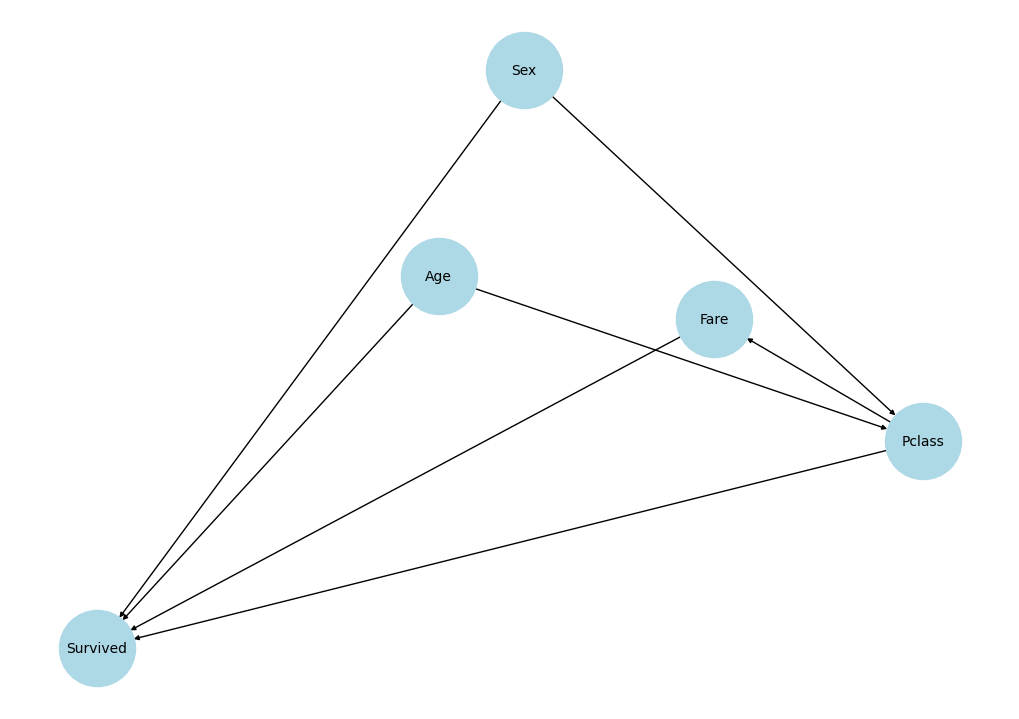

In [10]:
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(dag, seed=42)

nx.draw(
    dag,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    arrowsize=7,
    font_size=10
)

plt.show()

In [3]:
# Preparamos variables limpias:
# - deck_known: proxy de camarote/ubicación (A, B, C suelen estar en cubiertas superiores)
df['deck_known'] = df['deck'].notna().astype(int)
df['is_female'] = (df['sex'] == 'female').astype(int)
df['is_pclass1'] = (df['pclass'] == 1).astype(int)


In [4]:
# Filtramos filas completas para una comparación justa entre modelos
df_clean = df.dropna(subset=['survived', 'pclass', 'age', 'fare']).copy()

In [5]:
df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,deck_known,is_female,is_pclass1
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0,0,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1,1,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0,1,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1,1,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0,0,0
